#### PCA on Socio-Economic Variables of Countries

In [73]:
import numpy as np
import pandas as pd
import seaborn as sns
import scipy
import matplotlib.pyplot as plt
from matplotlib import cm
import warnings
np.random.seed(4702)
sns.set_style('whitegrid')
warnings.filterwarnings('ignore')

In [74]:
countries = pd.read_csv('countries/Country-data.csv', index_col = 'country')
print(countries.iloc[0:20, :].to_markdown(tablefmt = "grid"))

+---------------------+--------------+-----------+----------+-----------+----------+-------------+--------------+-------------+--------+
| country             |   child_mort |   exports |   health |   imports |   income |   inflation |   life_expec |   total_fer |   gdpp |
+=====================+==============+===========+==========+===========+==========+=============+==============+=============+========+
| Afghanistan         |         90.2 |      10   |     7.58 |      44.9 |     1610 |       9.44  |         56.2 |        5.82 |    553 |
+---------------------+--------------+-----------+----------+-----------+----------+-------------+--------------+-------------+--------+
| Albania             |         16.6 |      28   |     6.55 |      48.6 |     9930 |       4.49  |         76.3 |        1.65 |   4090 |
+---------------------+--------------+-----------+----------+-----------+----------+-------------+--------------+-------------+--------+
| Algeria             |         27.3 |   

In [75]:
n, p = countries.shape
print(f'Observations (Countries): {n}')
print(f'Variables: {p}')
print()

X = countries.values

# Sample Mean Vector
mu = (1/n) * X.T @ np.ones((n,1))
print('Mean Vector: ')
print(pd.DataFrame(mu, index = countries.columns, columns = ['Mean']).to_markdown(tablefmt="grid"))

Observations (Countries): 167
Variables: 9

Mean Vector: 
+------------+-------------+
|            |        Mean |
+============+=============+
| child_mort |    38.2701  |
+------------+-------------+
| exports    |    41.109   |
+------------+-------------+
| health     |     6.81569 |
+------------+-------------+
| imports    |    46.8902  |
+------------+-------------+
| income     | 17144.7     |
+------------+-------------+
| inflation  |     7.78183 |
+------------+-------------+
| life_expec |    70.5557  |
+------------+-------------+
| total_fer  |     2.94796 |
+------------+-------------+
| gdpp       | 12964.2     |
+------------+-------------+


In [76]:
# Sample Covariance Matrix (S)
Q = np.ones((n, 1)) @ mu.T
S = (1/(n-1)) * (X - Q).T @  (X - Q)

print('\nCovariance Matrix:')
print(pd.DataFrame(S, index = countries.columns, columns = countries.columns).to_markdown(tablefmt="grid"))


Covariance Matrix:
+------------+--------------+--------------+--------------+-------------+-------------------+--------------+--------------+---------------+-------------------+
|            |   child_mort |      exports |       health |     imports |            income |    inflation |   life_expec |     total_fer |              gdpp |
+============+==============+==============+==============+=============+===================+==============+==============+===============+===================+
| child_mort |    1626.42   |   -351.651   |   -22.1999   |  -124.202   | -407636           |    122.894   |   -318.008   |     51.8012   | -357046           |
+------------+--------------+--------------+--------------+-------------+-------------------+--------------+--------------+---------------+-------------------+
| exports    |    -351.651  |    751.418   |    -8.61453  |   489.351   |  273095           |    -31.0901  |     77.1106  |    -13.2797   |  210378           |
+------------+------

##### Eigen-Decomposition of Covariance Matrix (S)

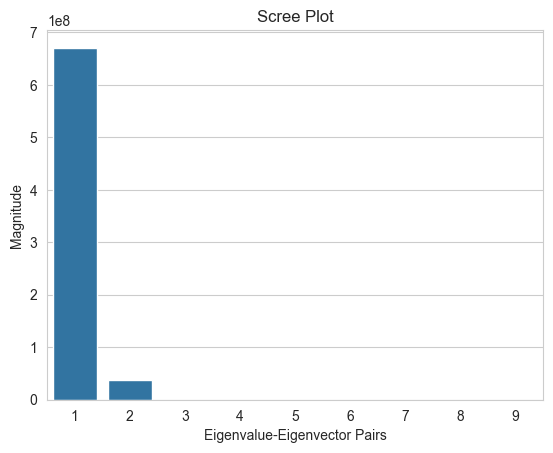

In [77]:
cov_eigen_values, cov_eigen_vectors = np.linalg.eig(S)

sorted_indices = np.argsort(cov_eigen_values)[::-1]
cov_eigen_values = cov_eigen_values[sorted_indices]
cov_eigen_vectors = cov_eigen_vectors[:, sorted_indices]

# Scree plot will show how much variance is captured by each eigenvector-eigenvalue pair
sns.barplot(x = range(1,10), y = cov_eigen_values)
plt.title('Scree Plot')
plt.xlabel('Eigenvalue-Eigenvector Pairs')
plt.ylabel('Magnitude')
plt.show()

In [78]:
# Proportions of Total Variance attributed to Principal components

total_variance = sum(cov_eigen_values)
total_variance

explained_variance = 100 * cov_eigen_values / total_variance

for i in range(p):
    print(f'PC{i+1} : {explained_variance[i]:.5f}%')

print(f'\nPC1 & PC2 Proportion of Explained Variance: {explained_variance[0] + explained_variance[1]:.5f}%')

PC1 : 94.79231%
PC2 : 5.20735%
PC3 : 0.00018%
PC4 : 0.00014%
PC5 : 0.00002%
PC6 : 0.00001%
PC7 : 0.00000%
PC8 : 0.00000%
PC9 : 0.00000%

PC1 & PC2 Proportion of Explained Variance: 99.99965%


Thus we can project our data onto the 2 Principal Components without losing signaificant variance within the data.

In [79]:
Y = X @ cov_eigen_vectors[:, 0:2]

In [80]:
# Linear Combination of PC1 & PC2

for i in range(2):
    print(f'PC{i+1} = ', end = '')
    for j in range(p):
        print(f'{cov_eigen_vectors[j, i]:.4f} * X{j+1} ', end = '')
        if (j != p - 1):
            print('+ ', end = '')
    print()

PC1 = 0.0008 * X1 + -0.0005 * X2 + -0.0000 * X3 + -0.0001 * X4 + -0.7267 * X5 + 0.0001 * X6 + -0.0002 * X7 + 0.0000 * X8 + -0.6869 * X9 
PC2 = -0.0006 * X1 + 0.0009 * X2 + -0.0002 * X3 + 0.0001 * X4 + 0.6869 * X5 + 0.0003 * X6 + 0.0000 * X7 + -0.0000 * X8 + -0.7267 * X9 


In [81]:
descriptions = pd.read_csv('countries/data-dictionary.csv')

print('Variable Descriptions')
for i in range(1, descriptions.shape[0]):
    print(f'X{i} {descriptions.iloc[i, 0]} : {descriptions.iloc[i, 1]}')

Variable Descriptions
X1 child_mort : Death of children under 5 years of age per 1000 live births
X2 exports : Exports of goods and services. Given as %age of the Total GDP
X3 health : Total health spending as %age of Total GDP
X4 imports : Imports of goods and services. Given as %age of the Total GDP
X5 Income : Net income per person
X6 Inflation : The measurement of the annual growth rate of the Total GDP
X7 life_expec : The average number of years a new born child would live if the current mortality patterns are to remain the same
X8 total_fer : The number of children that would be born to each woman if the current age-fertility rates remain the same.
X9 gdpp : The GDP per capita. Calculated as the Total GDP divided by the total population.


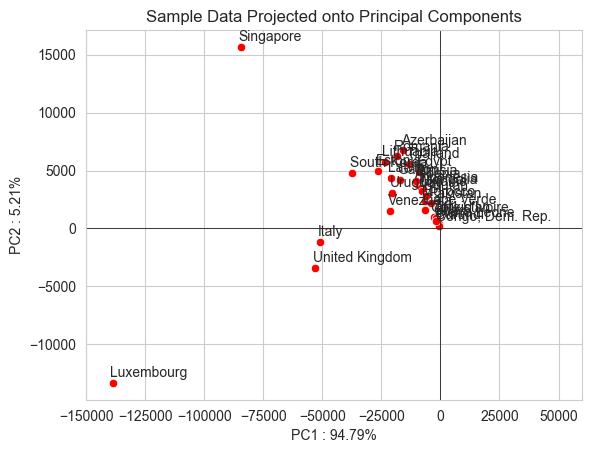

In [82]:
pca_countries = pd.DataFrame(Y, columns = ['PC1', 'PC2'])
pca_countries['COUNTRY'] = countries.index
pca_countries = pca_countries[['COUNTRY', 'PC1', 'PC2']]
sample = pca_countries.sample(n = 30)

sns.scatterplot(x = sample.iloc[:, 1], y = sample.iloc[:, 2], c = 'r')
plt.title('Sample Data Projected onto Principal Components')
plt.axhline(y = 0, c = 'k', linewidth = 0.5)
plt.axvline(x = 0, c = 'k', linewidth = 0.5)
plt.xlim((-150000, 60000))
plt.xlabel(f'PC1 : {explained_variance[0]:.2f}%')
plt.ylabel(f'PC2 : {explained_variance[1]:.2f}%')

for i in range(30):
    text = sample.iloc[i, 0]
    plt.text(s = text, x = sample.iloc[i, 1] - 1000, y = sample.iloc[i, 2] + 500, size = 10)

plt.show()

In [83]:
# This analysis is highly inaccurate because both principle components are made up mostly of
# income and gdp/capita which are both on higher scales relative to other variables.

# Because of this we must standardize our variables and use the eigen-decomposition of the correlation matrix.

#### PCA using Correlation Matrix (R)

In [84]:
# Correlation Matrix (S)

V = np.sqrt(np.diag(np.diag(S)))
V_inv = np.linalg.inv(V)

R = V_inv @ S @ V_inv
print(pd.DataFrame(R, index = countries.columns, columns = countries.columns).to_markdown(tablefmt="grid"))

+------------+--------------+-----------+------------+------------+-----------+-------------+--------------+-------------+-----------+
|            |   child_mort |   exports |     health |    imports |    income |   inflation |   life_expec |   total_fer |      gdpp |
+============+==============+===========+============+============+===========+=============+==============+=============+===========+
| child_mort |     1        | -0.318093 | -0.200402  | -0.127211  | -0.524315 |    0.288276 |   -0.886676  |    0.848478 | -0.483032 |
+------------+--------------+-----------+------------+------------+-----------+-------------+--------------+-------------+-----------+
| exports    |    -0.318093 |  1        | -0.114408  |  0.737381  |  0.516784 |   -0.107294 |    0.316313  |   -0.320011 |  0.418725 |
+------------+--------------+-----------+------------+------------+-----------+-------------+--------------+-------------+-----------+
| health     |    -0.200402 | -0.114408 |  1         | 

In [85]:
# Standardized Data Matrix

Z = (X - Q) @ V_inv
print(pd.DataFrame(Z, columns = countries.columns, index = countries.index).iloc[0:10, :].to_markdown(tablefmt="grid"))

+---------------------+--------------+------------+------------+------------+------------+-------------+--------------+-------------+------------+
| country             |   child_mort |    exports |     health |    imports |     income |   inflation |   life_expec |   total_fer |       gdpp |
+=====================+==============+============+============+============+============+=============+==============+=============+============+
| Afghanistan         |    1.28766   | -1.13487   |  0.278251  | -0.0822077 | -0.805822  |  0.156864   |    -1.61424  |   1.89718   | -0.677143  |
+---------------------+--------------+------------+------------+------------+------------+-------------+--------------+-------------+------------+
| Albania             |   -0.537333  | -0.47822   | -0.0967253 |  0.0706243 | -0.374243  | -0.311411   |     0.645924 |  -0.857394  | -0.484167  |
+---------------------+--------------+------------+------------+------------+------------+-------------+--------------

##### Eigen-Decomposition of R

In [86]:
corr_eigen_values, corr_eigen_vectors = np.linalg.eig(R)

# Sorting Eigen-Decomposition in order of greatest variance (eigenvalue)
sorted_indices = np.argsort(corr_eigen_values)[::-1]
corr_eigen_values = corr_eigen_values[sorted_indices]
corr_eigen_vectors = corr_eigen_vectors[:, sorted_indices]

corr_eigen_values

array([4.13565658, 1.54634631, 1.1703833 , 0.99478456, 0.66061903,
       0.22358112, 0.11343874, 0.08831536, 0.06687501])

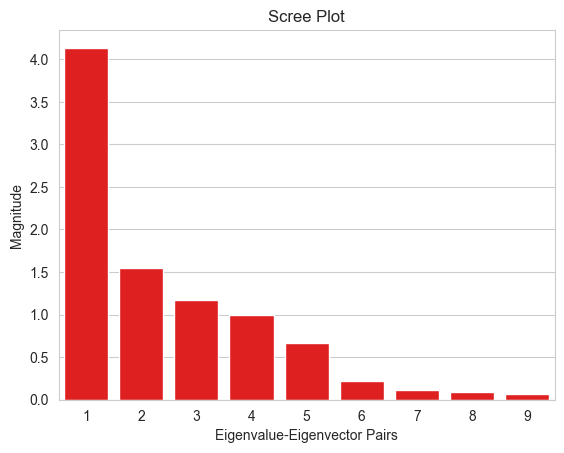

In [87]:
sns.barplot(x = range(1,10), y = corr_eigen_values, color = 'red')
plt.title('Scree Plot')
plt.xlabel('Eigenvalue-Eigenvector Pairs')
plt.ylabel('Magnitude')
plt.show()

In [88]:
total_variance = sum(corr_eigen_values)
total_variance

for i in range(p):
    print(f'PC{i+1} : {100 * corr_eigen_values[i] / total_variance:.5f}%')

explained_variance = 100 * corr_eigen_values / total_variance
print(f'\nPC1, PC2 & PC3 % of Explained Variance: {sum(explained_variance[0:3]):.5f}%')
print(f'PC1, PC2 & PC3 % of lost variance: {100 - sum(explained_variance[0:3]):.5f}%\n')

PC1 : 45.95174%
PC2 : 17.18163%
PC3 : 13.00426%
PC4 : 11.05316%
PC5 : 7.34021%
PC6 : 2.48423%
PC7 : 1.26043%
PC8 : 0.98128%
PC9 : 0.74306%

PC1, PC2 & PC3 % of Explained Variance: 76.13762%
PC1, PC2 & PC3 % of lost variance: 23.86238%



In [89]:
# PCs as linear combinations

for i in range(3):
    print(f'PC{i+1} = ', end = '')
    for j in range(p):
        print(f'{corr_eigen_vectors[j, i]:.4f} * Z{j+1} ', end = '')
        if (j != p - 1):
            print('+ ', end = '')
    print()

PC1 = 0.4195 * Z1 + -0.2839 * Z2 + -0.1508 * Z3 + -0.1615 * Z4 + -0.3984 * Z5 + 0.1932 * Z6 + -0.4258 * Z7 + 0.4037 * Z8 + -0.3926 * Z9 
PC2 = -0.1929 * Z1 + -0.6132 * Z2 + 0.2431 * Z3 + -0.6718 * Z4 + -0.0225 * Z5 + 0.0084 * Z6 + 0.2227 * Z7 + -0.1552 * Z8 + 0.0460 * Z9 
PC3 = 0.0295 * Z1 + -0.1448 * Z2 + 0.5966 * Z3 + 0.2999 * Z4 + -0.3015 * Z5 + -0.6425 * Z6 + -0.1139 * Z7 + -0.0195 * Z8 + -0.1230 * Z9 


***Analysis of Coefficients***

***PC1 Analysis:***   

Z7 (Life Expectancy) : $ -0.4258 $  
Z8 (Total Fertility) : $ 0.4037 $   
Z1 (Child Mortality) : $ 0.4195 $   
Z9 (GDP per Capita)  : $ -0.3926 $  
Z5 (Income)          : $ -0.3984 $  

We can interpret PC1 as a Development Index since weighting is focused on developmental factors.    
Countries high in PC1 are likely developing countries with lower income, higher birth rates and higher child mortalities.

***PC2 Analysis:***   

Z2 (Imports) : $ -0.6132 $  
Z4 (Exports) : $ -0.6718 $  

We can interpret PC2 as a Global Trade Volume Index since weights are focused on imports and exports.   
Countries high in PC2 are likely to be less active in global market participation while countries low in PC2 are more engaged in global trade.

***PC3 Analysis:***   

Z3 (Health Spending) : $ 0.5966 $  
Z6 (Inflation)       : $ -0.6132 $  

Finally, we can interpret PC3 as the trade-off between health spending and inflation.   
Countries high in PC3 are likely to have economies with governments spending relatively more on healthcare while keeping inflation in check.    
Countries low in PC3 are likely to have economies that do not spend on healthcare but struggle to prevent prices from rising.

***Weight Adjustments***: To have PC1 reflect how developed a country is and have PC2 reflect how much global trade a country participates in, we multiply their eigenvectors by -1

In [90]:
corr_eigen_vectors[:, 0:2] *= -1
print(pd.DataFrame(corr_eigen_vectors[:, 0:3], columns=['E1', 'E2', 'E3']).to_markdown(tablefmt = "grid"))

+----+-----------+-------------+------------+
|    |        E1 |          E2 |         E3 |
+====+===========+=============+============+
|  0 | -0.419519 |  0.192884   |  0.0295435 |
+----+-----------+-------------+------------+
|  1 |  0.283897 |  0.613163   | -0.144761  |
+----+-----------+-------------+------------+
|  2 |  0.150838 | -0.243087   |  0.596632  |
+----+-----------+-------------+------------+
|  3 |  0.161482 |  0.671821   |  0.299927  |
+----+-----------+-------------+------------+
|  4 |  0.398441 |  0.0225355  | -0.301548  |
+----+-----------+-------------+------------+
|  5 | -0.193173 | -0.00840447 | -0.64252   |
+----+-----------+-------------+------------+
|  6 |  0.425839 | -0.222707   | -0.113919  |
+----+-----------+-------------+------------+
|  7 | -0.403729 |  0.155233   | -0.0195492 |
+----+-----------+-------------+------------+
|  8 |  0.392645 | -0.0460224  | -0.122977  |
+----+-----------+-------------+------------+


In [91]:
Y = Z @ corr_eigen_vectors[:, 0:3]

In [92]:
pca_countries = pd.DataFrame(Y, index = countries.index, columns = ['PC1', 'PC2', 'PC3'])
print(pca_countries.iloc[0:10, :].to_markdown(tablefmt = "grid"))

+---------------------+------------+------------+-----------+
| country             |        PC1 |        PC2 |       PC3 |
+=====================+============+============+===========+
| Afghanistan         | -2.90429   |  0.0953339 |  0.715965 |
+---------------------+------------+------------+-----------+
| Albania             |  0.428622  | -0.586392  |  0.332486 |
+---------------------+------------+------------+-----------+
| Algeria             | -0.28437   | -0.45381   | -1.21784  |
+---------------------+------------+------------+-----------+
| Angola              | -2.92363   |  1.69047   | -1.52047  |
+---------------------+------------+------------+-----------+
| Antigua and Barbuda |  1.03048   |  0.136249  |  0.225044 |
+---------------------+------------+------------+-----------+
| Argentina           |  0.0223401 | -1.77385   | -0.867388 |
+---------------------+------------+------------+-----------+
| Armenia             | -0.101279  | -0.566548  | -0.241366 |
+-------

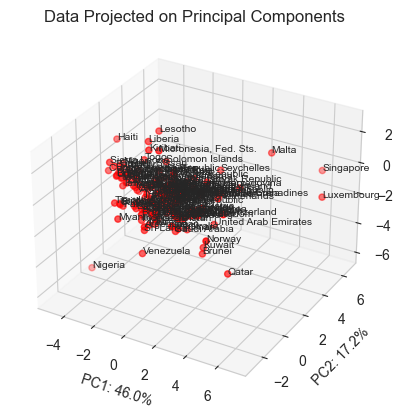

In [93]:
# Projecting All Data

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.set_title('Data Projected on Principal Components')
ax.scatter(xs = Y[:, 0], ys = Y[:, 1], zs = Y[:, 2], c = 'r')
ax.set_xlabel(f'PC1: {explained_variance[0]:.1f}%')
ax.set_ylabel(f'PC2: {explained_variance[1]:.1f}%')
ax.set_zlabel(f'PC3: {explained_variance[2]:.1f}%')

for i in range(n):
    text = countries.index[i]
    ax.text(Y[i, 0], Y[i, 1], Y[i, 2], text, size = 7.5)

plt.show()

IndexError: single positional indexer is out-of-bounds

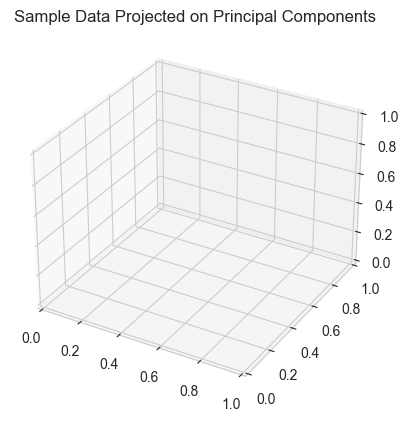

In [94]:
# Projecting Sample Data

sample = pca_countries.sample(n = 20)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.set_title('Sample Data Projected on Principal Components')
ax.scatter(xs = sample.iloc[:, 1], ys = sample.iloc[:, 2], zs = sample.iloc[:, 3], c = 'r')
ax.set_xlabel(f'PC1: {explained_variance[0]:.1f}%')
ax.set_ylabel(f'PC2: {explained_variance[1]:.1f}%')
ax.set_zlabel(f'PC3: {explained_variance[2]:.1f}%')

for i in range(20):
    text = sample.iloc[i, 0]
    ax.text(sample.iloc[i, 1], sample.iloc[i, 2], sample.iloc[i, 3], text, size = 10)

plt.show()

***Pre-PCA Diagnosis***   
The main idea behind Principal Component Analysis is taking advantage of relationships between variables. To make sure this relationship actually exists, we need to confirm whether the data cloud has prominent directions of if it is actually spherical.To do this, we can conduct PCA and see if proportions of variance captured across principal components are similar. Although, if we conduct Bartlett's test for Sphericity, we can skip the computations involved in projecting data onto principal components. 

*Assumptions of Bartlett's Test:* 
- Multivariate Normality of the Data Matrix
- Continuous random variables
- Independence between samples

*Hypothesis  Test*

$$ H_0: R = I $$
$$ H_a: R \neq I $$

We assume the test statistic follows a Chi-Square Distribution with the following degrees of freedom being the amount of unique pairwise correlations:

$$ \chi^2 = - \left( n - 1 - \frac{2p + 5}{6} \right) \ln(\vert{}R\vert{}) $$
$$ df = \frac{p(p - 1)}{2} $$

- $n$ : Number of observations
- $p$ : Number of variables
- $R$ : Sample correlation matrix

We conduct this test with $95$% confidence and set $ \alpha = 0.05 $

In [ ]:
alpha = 0.05
test_statistic = -(n - 1 - (2*p + 5)/6) * np.log(np.linalg.det(R))
p_value = 1 - scipy.stats.chi2.cdf(test_statistic, df = 0.5 * p * (p-1))
critical_value = scipy.stats.chi2.ppf(1-alpha, df = 0.5 * p * (p-1))

print(f'Test Statistic: {test_statistic:.2f}')
print(f'p-value: {p_value}')
print(f'Critical value: {critical_value:.2f}')

print(f"\nWith {100 * (1-alpha)} % confidence:")
if p_value < alpha:
    print("REJECT H0: Data is sufficiently correlated. PCA is safe to do.")
else:
    print("FAIL TO REJECT H0: Data is likely uncorrelated. Investigate the data...")

Test Statistic: 1169.74
p-value: 0.0
Critical value: 51.00

With 95.0 % confidence:
REJECT H0: Data is sufficiently correlated.
